# SPID inverted-pendulum: 10-seed analysis

This notebook analyzes the complete `ten_seeds_pilot` run. It reads all metrics and summaries from the directory containing the notebook, so the run can be moved without changing paths.

In [17]:
from pathlib import Path
import json

import jax
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (10, 5), "figure.dpi": 120})

run_dir = Path.cwd()
if not (run_dir / "config.json").exists():
    candidates = list(Path.cwd().rglob("ten_seeds_pilot/config.json"))
    if not candidates:
        raise FileNotFoundError("Could not locate ten_seeds_pilot/config.json")
    run_dir = candidates[0].parent

config = json.loads((run_dir / "config.json").read_text())
summary = json.loads((run_dir / "aggregate_summary.json").read_text())
aggregate = pd.read_csv(run_dir / "aggregate_results.csv")
metrics = pd.concat(
    [pd.read_csv(path).assign(seed=int(path.parent.name.split("_")[1]))
     for path in sorted(run_dir.glob("seed_*/metrics.csv"))],
    ignore_index=True,
)
metrics["gm_loss_finite"] = metrics["gm_loss"].where(np.isfinite(metrics["gm_loss"]))
print(f"Loaded {len(aggregate)} seeds and {len(metrics)} recorded iterations from {run_dir}")
pd.Series(config, name="value").to_frame()

Loaded 10 seeds and 63 recorded iterations from /home/gnadizar/PycharmProjects/genepax/distillation_experiments/repertoires/spid_inverted_pendulum/ten_seeds_pilot


,value
backend,generalized
dataset_batch_size,4096
env,inverted_pendulum
evaluation_trajectories,10
expert_fraction,0.25
expert_weight_end,None
expert_weight_start,0.5
gm_alpha,0.1
gm_epsilon,0.1
iterations,10


## Aggregate outcome

,value
completed_seeds,10.000000
mean_best_validation_reward,745.190000
median_best_validation_reward,1000.000000
min_best_validation_reward,198.800003
max_best_validation_reward,1000.000000
population_std_best_validation_reward,343.643066
solved_fraction,0.600000
solved_seeds,6.000000
total_seeds,10.000000


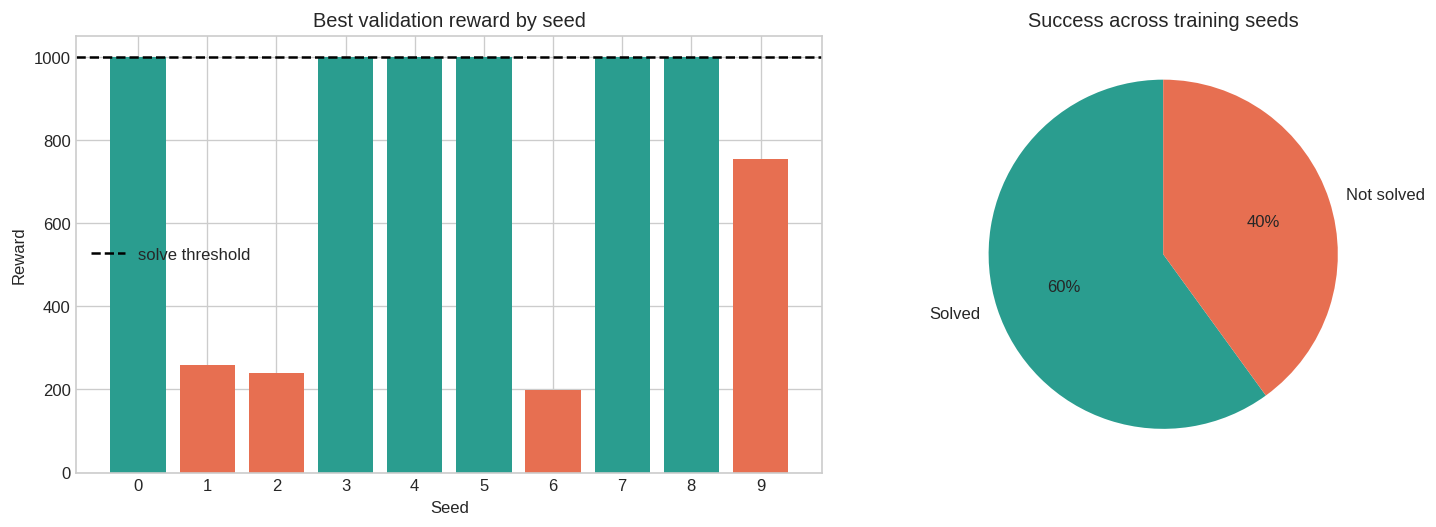

In [18]:
display(pd.Series(summary, name="value").to_frame())

colors = np.where(aggregate["solved"], "#2a9d8f", "#e76f51")
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(aggregate["seed"], aggregate["best_validation_reward"], color=colors)
axes[0].axhline(config["target_reward"], color="black", linestyle="--", label="solve threshold")
axes[0].set(title="Best validation reward by seed", xlabel="Seed", ylabel="Reward", xticks=aggregate["seed"])
axes[0].legend()
solved_counts = aggregate["solved"].value_counts().reindex([True, False], fill_value=0)
axes[1].pie(solved_counts, labels=["Solved", "Not solved"], autopct="%1.0f%%", colors=["#2a9d8f", "#e76f51"], startangle=90)
axes[1].set_title("Success across training seeds")
plt.tight_layout();

## Symbolic-policy learning curves

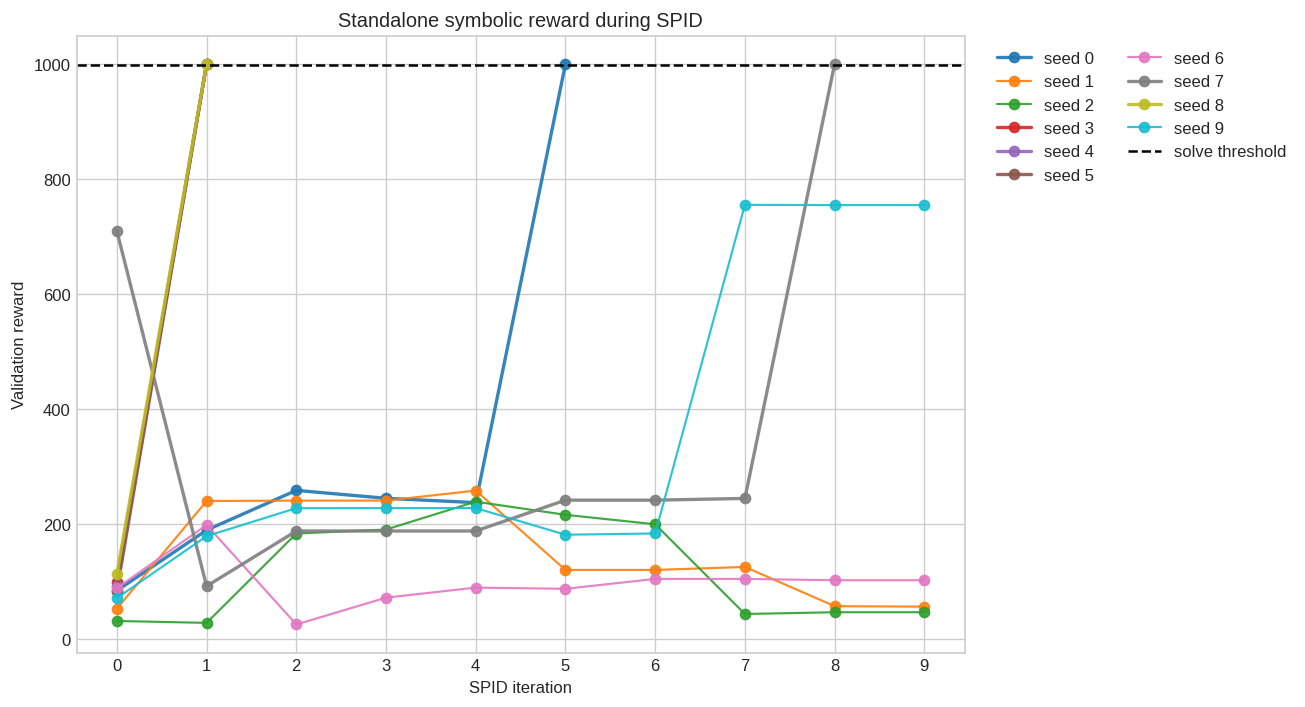

In [19]:
fig, ax = plt.subplots(figsize=(11, 6))
for seed, frame in metrics.groupby("seed"):
    solved = bool(aggregate.loc[aggregate.seed == seed, "solved"].iloc[0])
    ax.plot(frame["iteration"], frame["symbolic_reward"], marker="o", linewidth=2 if solved else 1.3, alpha=0.9, label=f"seed {seed}")
ax.axhline(config["target_reward"], color="black", linestyle="--", label="solve threshold")
ax.set(title="Standalone symbolic reward during SPID", xlabel="SPID iteration", ylabel="Validation reward", xticks=range(config["iterations"]))
ax.legend(ncol=2, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout();

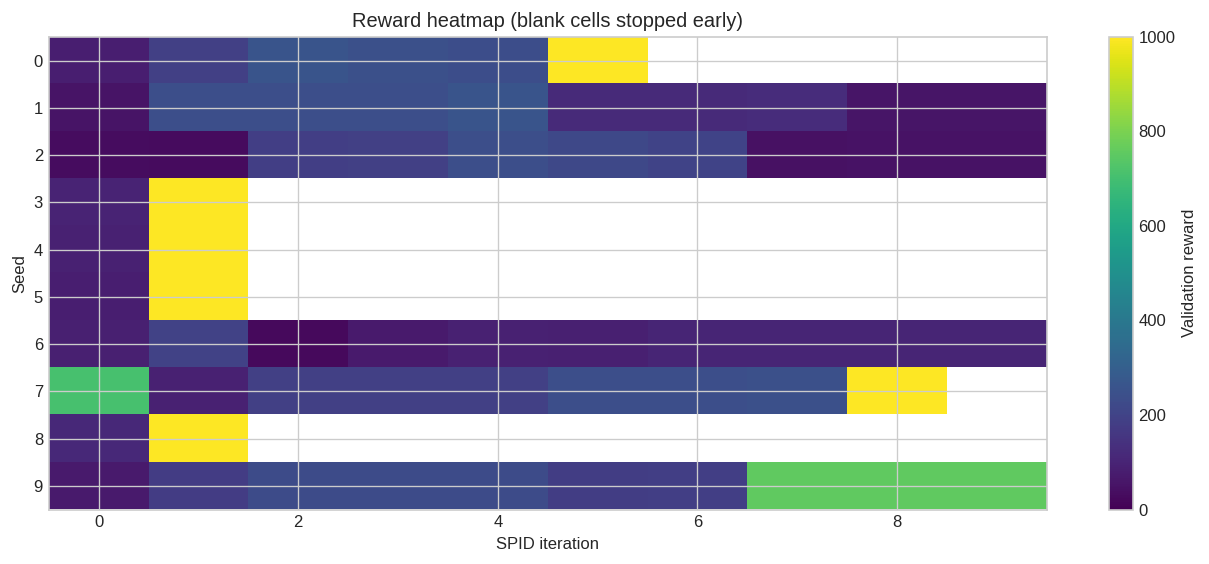

In [20]:
pivot = metrics.pivot(index="seed", columns="iteration", values="symbolic_reward")
fig, ax = plt.subplots(figsize=(11, 4.8))
image = ax.imshow(pivot, aspect="auto", cmap="viridis", vmin=0, vmax=config["rollout_steps"])
ax.set(title="Reward heatmap (blank cells stopped early)", xlabel="SPID iteration", ylabel="Seed", yticks=range(len(pivot)), yticklabels=pivot.index)
fig.colorbar(image, ax=ax, label="Validation reward")
plt.tight_layout();

## GM loss and its relationship to control reward

Non-finite losses are marked separately. Loss values from different iterations are measured on changing aggregated datasets, so they are not directly comparable like a fixed validation loss.

Non-finite loss rows: 0


,gm_loss,symbolic_reward
gm_loss,1.000000,0.296778
symbolic_reward,0.296778,1.000000


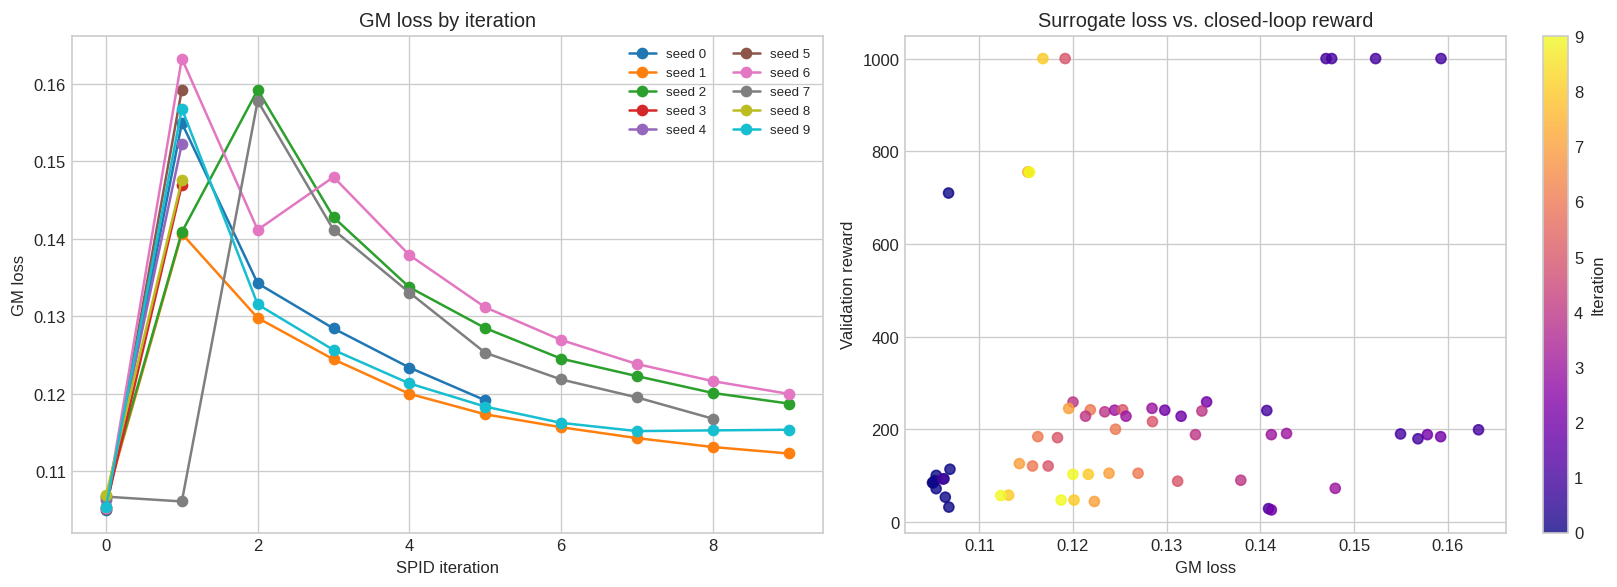

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for seed, frame in metrics.groupby("seed"):
    axes[0].plot(frame["iteration"], frame["gm_loss_finite"], marker="o", label=f"seed {seed}")
non_finite = metrics[~np.isfinite(metrics["gm_loss"])]
if len(non_finite):
    ceiling = metrics["gm_loss_finite"].max() * 1.08
    axes[0].scatter(non_finite["iteration"], np.full(len(non_finite), ceiling), marker="x", s=80, color="red", label="non-finite loss")
axes[0].set(title="GM loss by iteration", xlabel="SPID iteration", ylabel="GM loss")
axes[0].legend(ncol=2, fontsize=8)
finite = metrics[np.isfinite(metrics["gm_loss"])]
scatter = axes[1].scatter(finite["gm_loss"], finite["symbolic_reward"], c=finite["iteration"], cmap="plasma", alpha=0.8)
axes[1].set(title="Surrogate loss vs. closed-loop reward", xlabel="GM loss", ylabel="Validation reward")
fig.colorbar(scatter, ax=axes[1], label="Iteration")
plt.tight_layout();
print(f"Non-finite loss rows: {len(non_finite)}")
finite[["gm_loss", "symbolic_reward"]].corr(method="spearman")

## Aggregation and mixed-policy safety

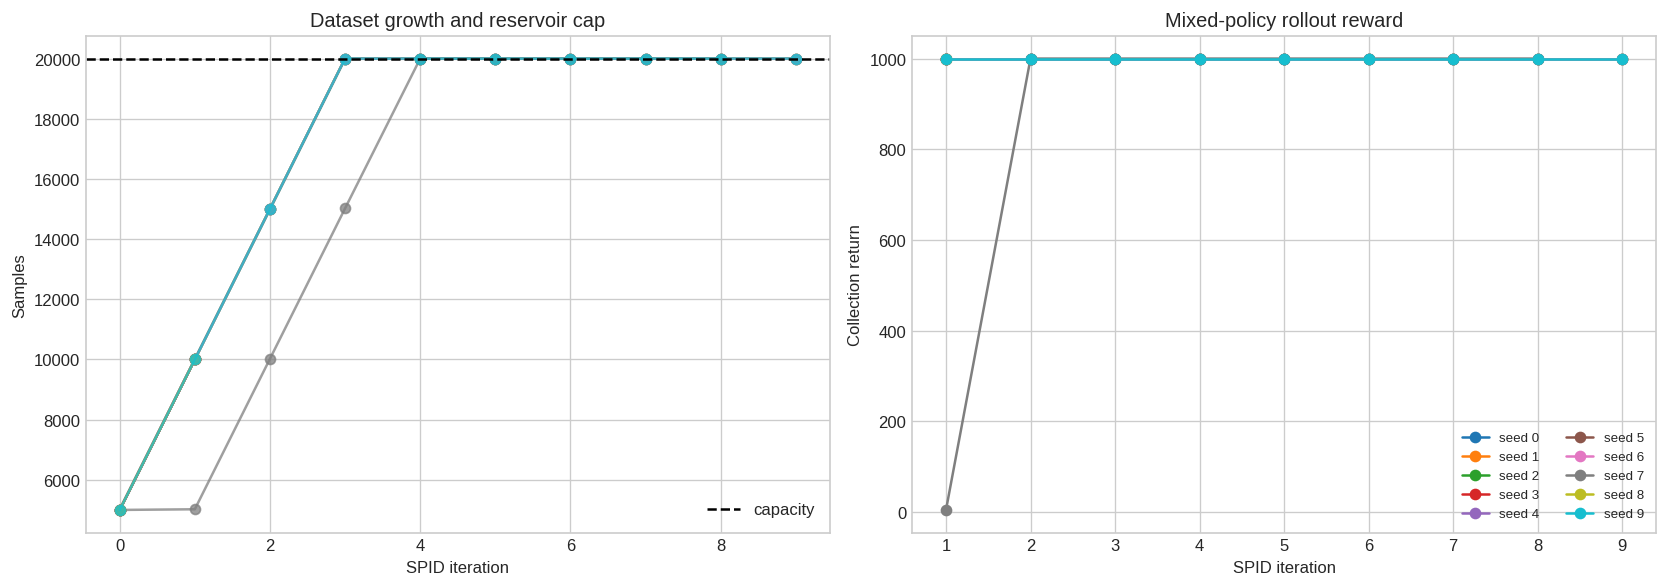

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for seed, frame in metrics.groupby("seed"):
    axes[0].plot(frame["iteration"], frame["dataset_size"], marker="o", alpha=0.75)
axes[0].axhline(config["max_dataset_size"], color="black", linestyle="--", label="capacity")
axes[0].set(title="Dataset growth and reservoir cap", xlabel="SPID iteration", ylabel="Samples")
axes[0].legend()
mixed = metrics.dropna(subset=["mixed_reward"])
for seed, frame in mixed.groupby("seed"):
    axes[1].plot(frame["iteration"], frame["mixed_reward"], marker="o", label=f"seed {seed}")
axes[1].set(title="Mixed-policy rollout reward", xlabel="SPID iteration", ylabel="Collection return")
axes[1].legend(ncol=2, fontsize=8)
plt.tight_layout();

## When was each saved controller found?

,seed,best_iteration,best_validation_reward,last_iteration,solved
0,0,5,1000.000000,5,True
1,1,4,258.600006,9,False
2,2,4,239.300003,9,False
3,3,1,1000.000000,1,True
4,4,1,1000.000000,1,True
5,5,1,1000.000000,1,True
6,6,1,198.800003,9,False
7,7,8,1000.000000,8,True
8,8,1,1000.000000,1,True
9,9,7,755.200012,9,False


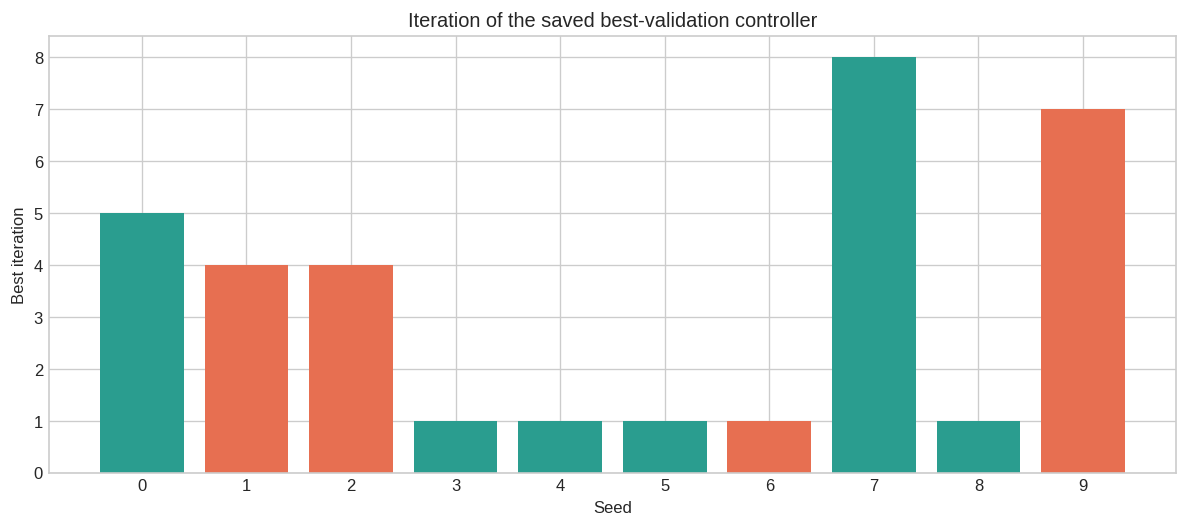

In [23]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(aggregate["seed"], aggregate["best_iteration"], color=colors)
ax.set(title="Iteration of the saved best-validation controller", xlabel="Seed", ylabel="Best iteration", xticks=aggregate["seed"])
plt.tight_layout();
aggregate

## Reloading a saved controller

The following cell demonstrates loading without evaluating. Evaluation additionally requires constructing the Brax environment.

In [24]:
import pickle
from genepax.gp.cartesian_genetic_programming import CGP

seed = 0
with open(run_dir / f"seed_{seed}" / "best_genotype.pickle", "rb") as file:
    genotype = pickle.load(file)
cgp = CGP(n_inputs=4, n_outputs=1)
jax.tree.map(lambda value: value.shape, genotype)

{'genes': {'functions': (50,),
  'inputs1': (50,),
  'inputs2': (50,),
  'outputs': (1,)},
 'weights': {'custom_weights': (0,),
  'functions': (50,),
  'functions_biases': (50,),
  'inputs1': (50,),
  'inputs1_biases': (50,),
  'inputs2': (50,),
  'inputs2_biases': (50,),
  'program_inputs': (2,)}}

## Best symbolic expressions

Expressions use descriptive names for the four Brax observations and include the CGP output wrapper.

In [26]:
input_names = {
    0: "cart_position",
    1: "pole_angle",
    2: "cart_velocity",
    3: "pole_angular_velocity",
}
output_names = {0: "action"}
expression_rows = []
for result in aggregate.itertuples(index=False):
    with open(run_dir / f"seed_{result.seed}" / "best_genotype.pickle", "rb") as file:
        best_genotype = pickle.load(file)
    expression = cgp.get_readable_expression(
        best_genotype,
        inputs_mapping=input_names,
        outputs_mapping=output_names,
    )
    expression_rows.append({
        "seed": result.seed,
        "best_iteration": result.best_iteration,
        "best_reward": result.best_validation_reward,
        "expression": expression,
    })

expression_table = pd.DataFrame(expression_rows)
with pd.option_context("display.max_colwidth", None):
    display(expression_table.style.hide(axis="index").set_properties(
        subset=["expression"], **{"text-align": "left"}
    ))

seed,best_iteration,best_reward,expression
0,5,1000.000000,action = tanh((((pole_angle*((exp(id(pole_angle))+cart_velocity)-cart_position))*exp(exp(id(pole_angle))))powexp(id(pole_angle))))
1,4,258.600006,action = tanh((pole_angle/sin(sqrt((sin(sqrt(cart_position))-abs(cart_position))))))
2,4,239.300003,action = tanh((((abs(cart_position)pow(sin(0.1)*abs(cart_position)))+(exp(sin(0.1))-sin(pole_angular_velocity)))*id(pole_angle)))
3,1,1000.000000,action = tanh(((pole_angular_velocitypowpole_angle)*(cos(cart_velocity)*pole_angle)))
4,1,1000.000000,action = tanh((((pole_angle-cart_position)pow(1.0+0.1))/sqrt(0.1)))
5,1,1000.000000,action = tanh(((pole_anglepowexp(pole_angular_velocity))pow((0.1pow1.0)pow0.1)))
6,1,198.800003,action = tanh((id(pole_angle)*exp(0.1)))
7,8,1000.000000,action = tanh(((pole_angle+pole_angle)powcos((abs(sqrt(pole_angular_velocity))+sin(cart_velocity)))))
8,1,1000.000000,action = tanh(sin(((pole_anglepowcart_velocity)powcart_velocity)))
9,7,755.200012,action = tanh((pole_anglepow(exp(abs(pole_angle))pow(log(cart_position)-1.0))))
